In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [19]:
offer_events = pd.read_csv("../data/synthetic_enrichment/offer_events.csv")

offer_events.head()

,event_id,subject_key,occurred_at,channel,arm_id,arm_name,reward_probability,reward,idade,profissao,...,numero_contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_preco_consumidor,indice_confianca_consumidor,taxa_euribor_3_meses,numero_empregados,conversao,cliente_ja_contatado,faixa_contatos
0,evt_000001,subject_000001,2025-01-01 00:00:00,whatsapp,0,sem_oferta,0.085,1,56,housemaid,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
1,evt_000002,subject_000002,2025-01-01 00:01:00,email,3,cartao_premium,0.105,0,57,services,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
2,evt_000003,subject_000003,2025-01-01 00:02:00,whatsapp,2,simulador_credito,0.155,0,37,services,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
3,evt_000004,subject_000004,2025-01-01 00:03:00,web,1,educacao_financeira,0.100,0,40,admin.,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
4,evt_000005,subject_000005,2025-01-01 00:04:00,email,1,educacao_financeira,0.105,0,56,services,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1


In [20]:
arms = sorted(offer_events["arm_id"].unique())

arm_names = (
    offer_events
    .drop_duplicates("arm_id")
    .set_index("arm_id")["arm_name"]
    .to_dict()
)

arms, arm_names

([np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
 {0: 'sem_oferta',
  3: 'cartao_premium',
  2: 'simulador_credito',
  1: 'educacao_financeira'})

In [21]:
reward_lookup = (
    offer_events
    .groupby("arm_id")["reward"]
    .mean()
    .to_dict()
)

reward_lookup

{0: 0.10599788196784442,
 1: 0.16149007273442106,
 2: 0.17305839275390247,
 3: 0.20060493706703092}

In [22]:
np.random.seed(42)

alpha = {arm: 1 for arm in arms}
beta = {arm: 1 for arm in arms}

results = []

n_rounds = 10000

for round_id in range(1, n_rounds + 1):

    samples = {
        arm: np.random.beta(alpha[arm], beta[arm])
        for arm in arms
    }

    chosen_arm = max(samples, key=samples.get)

    reward_probability = reward_lookup[chosen_arm]

    reward = np.random.binomial(
        n=1,
        p=reward_probability
    )

    if reward == 1:
        alpha[chosen_arm] += 1
    else:
        beta[chosen_arm] += 1

    results.append({
        "round": round_id,
        "arm_id": chosen_arm,
        "arm_name": arm_names[chosen_arm],
        "reward_probability": reward_probability,
        "reward": reward,
        "alpha_after": alpha[chosen_arm],
        "beta_after": beta[chosen_arm],
    })

ts_results = pd.DataFrame(results)

ts_results.head()

,round,arm_id,arm_name,reward_probability,reward,alpha_after,beta_after
0,1,0,sem_oferta,0.105998,0,1,2
1,2,3,cartao_premium,0.200605,0,1,2
2,3,1,educacao_financeira,0.161490,0,1,2
3,4,2,simulador_credito,0.173058,0,1,2
4,5,0,sem_oferta,0.105998,0,1,3


In [23]:
thompson_reward = ts_results["reward"].mean()

print(f"Reward médio Thompson Sampling: {thompson_reward:.2%}")

Reward médio Thompson Sampling: 19.23%


In [24]:
choice_distribution = (
    ts_results["arm_name"]
    .value_counts(normalize=True)
    .reset_index()
)

choice_distribution.columns = ["arm_name", "share"]
choice_distribution

,arm_name,share
0,cartao_premium,0.7443
1,simulador_credito,0.1843
2,educacao_financeira,0.0627
3,sem_oferta,0.0087


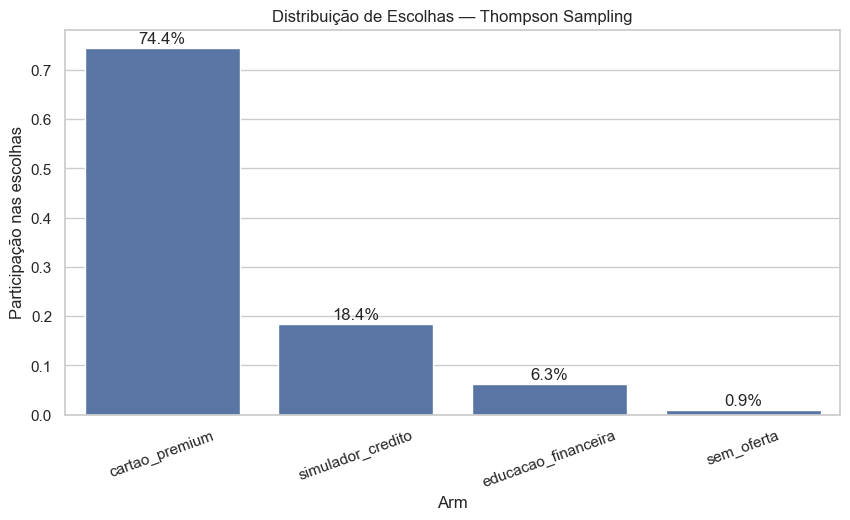

In [25]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=choice_distribution,
    x="arm_name",
    y="share"
)

for i, row in choice_distribution.iterrows():
    ax.text(
        i,
        row["share"] + 0.01,
        f"{row['share']:.1%}",
        ha="center"
    )

plt.title("Distribuição de Escolhas — Thompson Sampling")
plt.xlabel("Arm")
plt.ylabel("Participação nas escolhas")
plt.xticks(rotation=20)
plt.show()

In [26]:
ts_results["cumulative_reward"] = ts_results["reward"].cumsum()
ts_results["average_reward"] = (
    ts_results["cumulative_reward"] / ts_results["round"]
)

ts_results.head()

,round,arm_id,arm_name,reward_probability,reward,alpha_after,beta_after,cumulative_reward,average_reward
0,1,0,sem_oferta,0.105998,0,1,2,0,0.0
1,2,3,cartao_premium,0.200605,0,1,2,0,0.0
2,3,1,educacao_financeira,0.161490,0,1,2,0,0.0
3,4,2,simulador_credito,0.173058,0,1,2,0,0.0
4,5,0,sem_oferta,0.105998,0,1,3,0,0.0


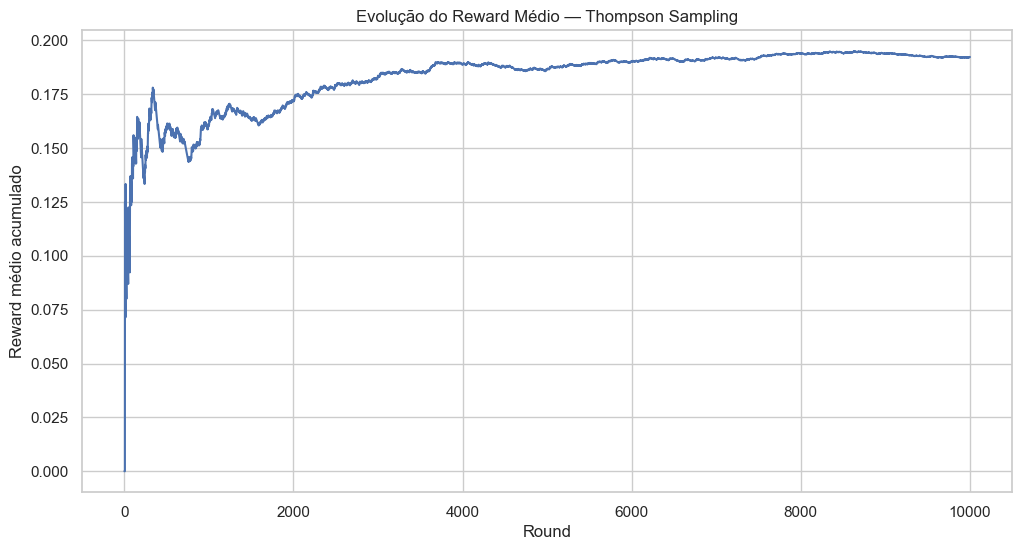

In [27]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=ts_results,
    x="round",
    y="average_reward"
)

plt.title("Evolução do Reward Médio — Thompson Sampling")
plt.xlabel("Round")
plt.ylabel("Reward médio acumulado")
plt.show()

In [28]:
random_baseline_reward = offer_events["reward"].mean()

comparison = pd.DataFrame([
    {
        "policy": "Random Baseline",
        "reward_mean": random_baseline_reward,
    },
    {
        "policy": "Thompson Sampling",
        "reward_mean": thompson_reward,
    }
])

comparison["reward_mean_pct"] = comparison["reward_mean"] * 100

comparison

,policy,reward_mean,reward_mean_pct
0,Random Baseline,0.160144,16.014373
1,Thompson Sampling,0.192300,19.230000


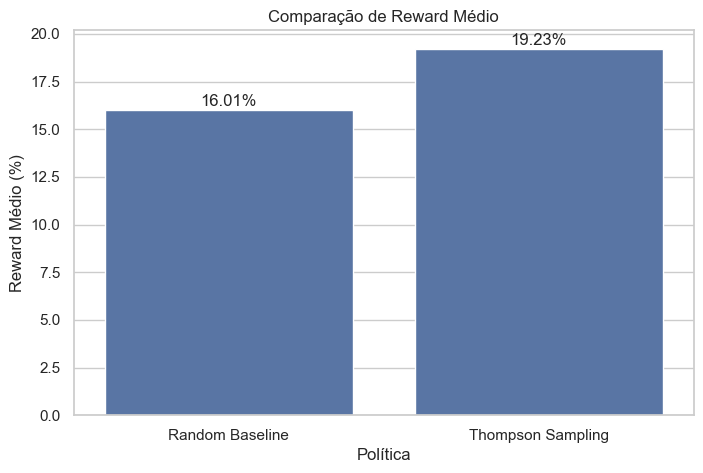

In [29]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=comparison,
    x="policy",
    y="reward_mean_pct"
)

for i, row in comparison.iterrows():
    ax.text(
        i,
        row["reward_mean_pct"] + 0.2,
        f"{row['reward_mean_pct']:.2f}%",
        ha="center"
    )

plt.title("Comparação de Reward Médio")
plt.xlabel("Política")
plt.ylabel("Reward Médio (%)")
plt.show()

In [30]:
uplift = (
    (thompson_reward - random_baseline_reward)
    / random_baseline_reward
)

print(f"Uplift Thompson Sampling vs Random Baseline: {uplift:.2%}")

Uplift Thompson Sampling vs Random Baseline: 20.08%


## Conclusão

O Thompson Sampling foi aplicado como política adaptativa para seleção de arms.

Inicialmente, todos os arms possuíam a mesma incerteza, representada por distribuições Beta(1,1). Ao longo das rodadas, a política passou a atualizar os parâmetros alpha e beta de cada arm conforme os rewards observados.

Os resultados indicam que o algoritmo concentrou progressivamente mais decisões nos arms com maior recompensa esperada, especialmente no arm com melhor desempenho sintético observado.

A comparação com a política aleatória demonstra o potencial da abordagem adaptativa para aumentar o reward médio e reduzir a alocação de tráfego em alternativas inferiores.